## Tutorial 2: Retrieve Aerosol Vertical Profile (AVP) using the TAMU TRACER data

Processing TAMU MPL Data
MPL files: ['/Users/bochen/TAMU/mplavp/example_data/tamu_minimpl/202208262100.mpl', '/Users/bochen/TAMU/mplavp/example_data/tamu_minimpl/202208262200.mpl']
/Users/bochen/TAMU/mplavp/example_data/tamu_radiosonde/TAMU_TRACER_20220826_2134_95.99W_30.09N_TSPOTINT.txt
Processing TAMU Radiosonde Data
TAMU Radiosonde Files: /Users/bochen/TAMU/mplavp/example_data/tamu_radiosonde/TAMU_TRACER_20220826_2134_95.99W_30.09N_TSPOTINT.txt
TAMU Raidosonde Launch Time is 2022-08-26T21:34:24


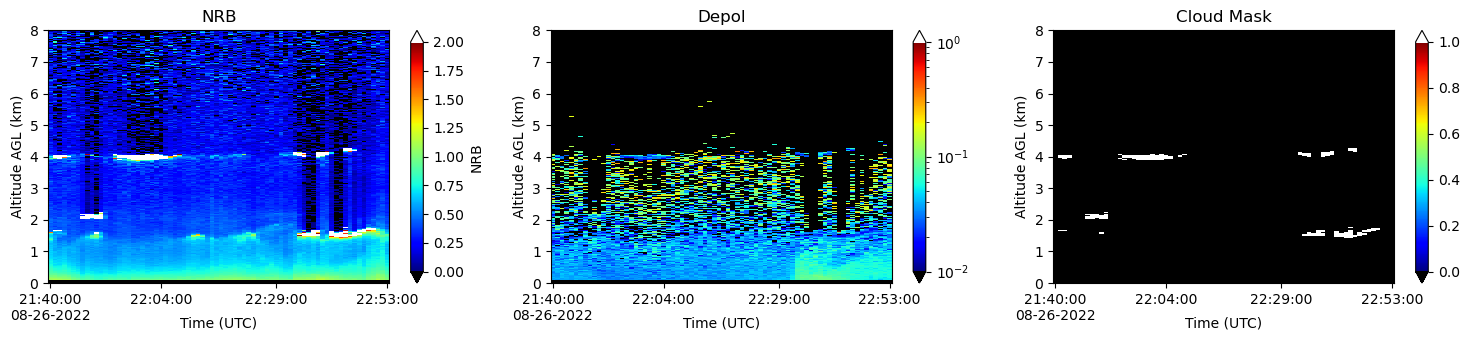

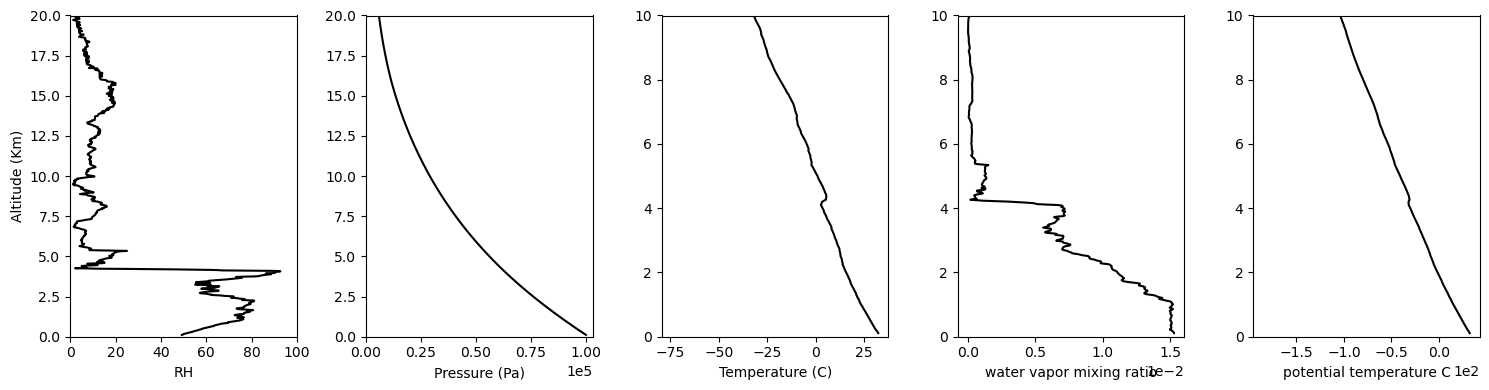

Processing TAMU Size Distribution Data
TAMU Sizedistribution date range: ['2022-08-26']


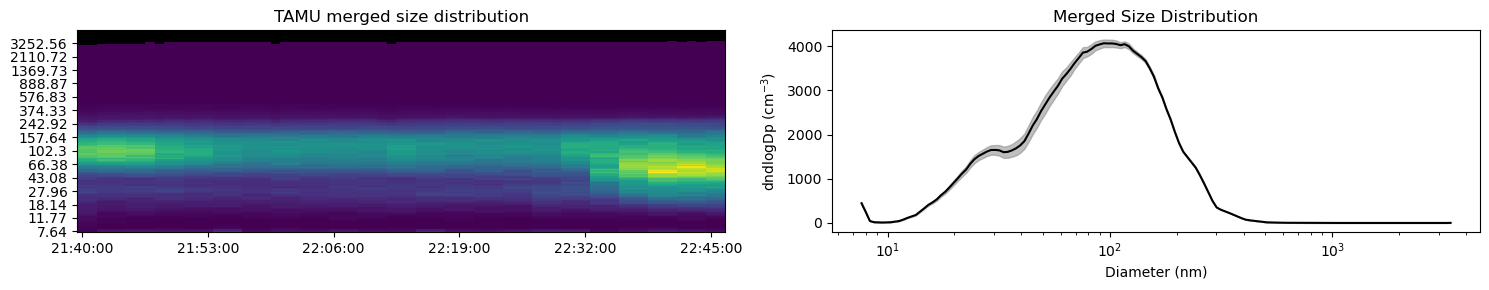

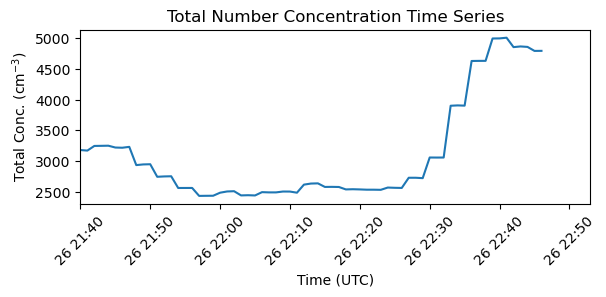

Processing TAMU CCN spectra Data
TAMU CCN spectra Files: ['tracer_tamu_220826_ccn.csv']


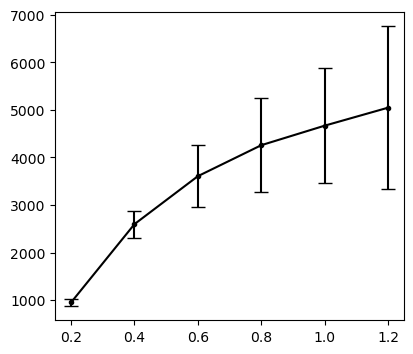

/Users/bochen/miniforge3/envs/Research/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


2022-08-26T21:40 to 2022-08-26T22:53 calculate kappa


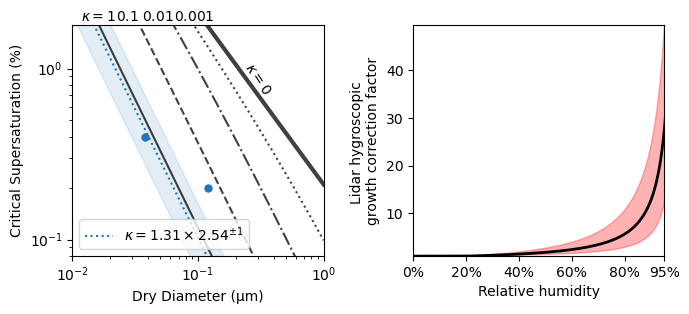

In [11]:
# import necessary python packages

import numpy as np
import matplotlib.pyplot as plt
import scipy
import os
import tracer_avp_processing
from pathlib import Path

# Initialize the data directory path. 
# Modify these paths as needed to point to your local data.

# ── Define project root ────────────────────────────────────────────────
# Adjust the `.parent` chain if your script lives at a different depth.
SCRIPT_DIR   = SCRIPT_DIR = Path.cwd().resolve()        # /…/mplavp/dev
PROJECT_ROOT = SCRIPT_DIR.parent                        # /…/mplavp

# ── Data & output folders (all under PROJECT_ROOT) ─────────────────────
EXAMPLE_DATA = PROJECT_ROOT / "example_data"
OUTPUT_DIR   = PROJECT_ROOT / "example_output"

# ── TAMU MPL raw data & calibration files ──────────────────────────────
tamu_mpl_dir_path                = EXAMPLE_DATA / "tamu_minimpl"

tamu_mpl_calib_dir               = EXAMPLE_DATA / "tamu_minimpl_calibration"
tamu_mpl_afterpulse_binary_path  = tamu_mpl_calib_dir / "MMPL5051_Afterpulse_202302161704_15m_energy_fixed.bin"
tamu_mpl_overlap_binary_path     = tamu_mpl_calib_dir / "MMPL5051_Overlap_202302211516_15m_energy_fixed.bin"
tamu_mpl_deadtime_binary_path    = tamu_mpl_calib_dir / "deadtime_correction_5051_SPCM34394_20230928.csv" # Use the custom CSV here, not the vendor *.bin: 
                                                                                                          # Vendor's calibration relies on an 11th-order polynomial fit to a calibration curve,
                                                                                                          # and the floating-point precision in the binary isn’t enough to keep it numerically sane.
                                                                                                          # (Lesson: never fit with an 11th-order polynomial.)

# ── Auxiliary ARM data ─────────────────────────────────────────────────
tamu_radiosonde_dir_path         = EXAMPLE_DATA / "tamu_radiosonde"
tamu_sizedist_dir_path           = EXAMPLE_DATA / "tamu_sizedist"
tamu_ccn_dir_path                = EXAMPLE_DATA / "tamu_CCN"


# ── Where processed files / plots will be written ──────────────────────
output_dir_path                 = OUTPUT_DIR


# –– Start and end time ––───────────────────────────────────────────────
start_time  = np.datetime64('2022-08-26T21:40')
end_time    = np.datetime64('2022-08-26T22:53')

calibration_range = 8
blind_zone = 0.1                # TAMU miniMPL has a blind zone of 100m
RH_upper_limit = 98


# –– Process MPL Data ––––──────────────────────────––─────────────────

tamumpl_data, cloud_mask, cloud_free_column, high_snr_depol, fig1, axs1 \
                = tracer_avp_processing.process_mpl_data(start_time, end_time, tamu_mpl_dir_path, 
                                                         tamu_mpl_afterpulse_binary_path, tamu_mpl_overlap_binary_path, tamu_mpl_deadtime_binary_path,
                                                         suffix = '*.mpl',
                                                         time_resolution = 60, mov_avg_win = None,
                                                         scale_num = 30, length_treshold = 25, value_treshold = 1.5, 
                                                         edge_treshold = 1.4, contain_cloud_treshold = 1.45, cloud_pixel_number_treshold = 2,
                                                         find_cloud_range = calibration_range,
                                                         snr_treshold = 5, not_a_cloud_treshold = 1.4,
                                                         blind_zone = blind_zone,
                                                         fig = None, axs = None, figsize = (15,3.5), plot_range_max = 8, 
                                                         savefig = True, showplot = True, output_folder = output_dir_path)

sonde_beta2, rh_interpolator, fig2, axs2 \
                = tracer_avp_processing.process_tamu_radiosonde_data(start_time, end_time, tamumpl_data.range, input_folder = tamu_radiosonde_dir_path,
                                                                    savefig = False, showplot = True, output_folder = output_dir_path)

merged_diameter, mean_dndlogdp, sem_dndlogdp, \
total_concentration, sem_total_concentration, merged_ri_n, fig3, axs3 \
            = tracer_avp_processing.process_tamu_mergedsizedist_data(start_time, end_time, input_folder = tamu_sizedist_dir_path,
                                                                    savefig = False, showplot = True, output_folder = output_dir_path)

ss_values, average_N_CCN, stdev_N_CCN, sem_N_CCN, CCN_data, fig4, axs4 \
            = tracer_avp_processing.process_tamu_CCN_data(start_time, end_time, input_folder = tamu_ccn_dir_path,
                                                            savefig = False, showplot = True, output_folder = output_dir_path)

fig8, axs8 = plt.subplots(nrows=1, ncols=2, figsize=(7.1,3.5))

gmean_kappa, gstd_kappa, all_kappa, _fig, _axs \
            = tracer_avp_processing.calculate_kappa_value(start_time, end_time, 
                                                        merged_diameter, mean_dndlogdp, ss_values, average_N_CCN, 
                                                        fig = fig8, axs = axs8[0],
                                                        savefig = False, showplot = False, output_folder = output_dir_path)

hf_interp, hf_high_interp, hf_low_interp, _fig, _axs  \
            = tracer_avp_processing.calculate_humidification_factor(start_time, end_time, 
                                                                    gmean_kappa, gstd_kappa,
                                                                    merged_diameter, mean_dndlogdp,
                                                                    rh_lim = 0.95, rh_dry = 0.2,
                                                                    fig = fig8, axs = axs8[1],
                                                                    wavelength = 532, ri_real = [1.44, 1.45, 1.46], ri_imaginary = 0, # 1.455
                                                                    savefig = True, showplot = True, 
                                                                    output_folder = output_dir_path,
                                                                    fig_name = f'{start_time}_{end_time}_Kappa and humidification factor')